# Chapter 04 - KNN and Distance Metrics
## Building Models with Distance Metrics and Nearest Neighbors
Based on scikit-learn Cookbook. This notebook explores K-Nearest Neighbors classification and the effect of choosing K.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
plt.style.use('ggplot')

## 1. Load Dataset (2 Features for Visualization)

In [2]:
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Dataset Scatter Plot

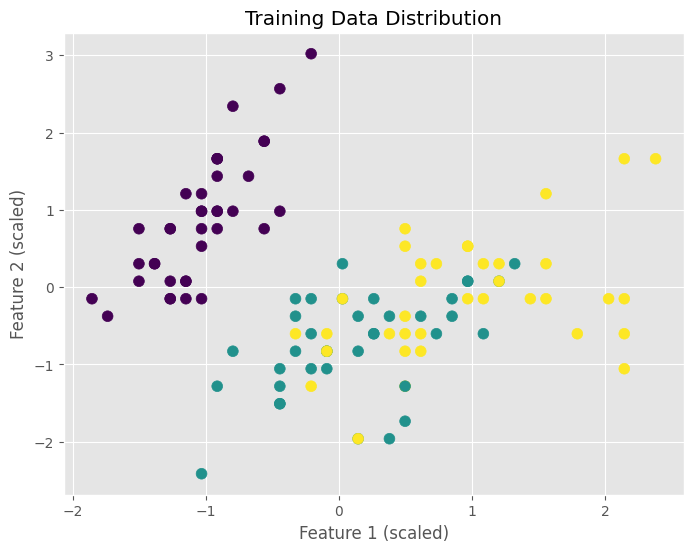

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=60)
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Training Data Distribution')
plt.show()

**Description:** KNN classifies new samples based on nearby labeled observations in feature space.

## 3. Accuracy for Different K Values

In [4]:
k_values = range(1,16)
acc_scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test,pred))
best_k = k_values[np.argmax(acc_scores)]
print('Best K:', best_k)

Best K: 9


## 4. K Selection Graph

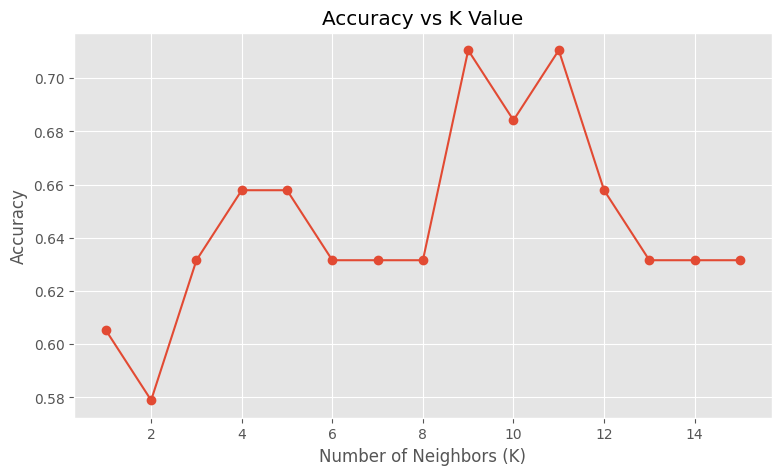

In [5]:
plt.figure(figsize=(9,5))
plt.plot(list(k_values), acc_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')
plt.show()

**Description:** Small K may overfit, while very large K may underfit. The graph helps choose a balanced K value.

## 5. Final Model with Best K

In [6]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train,y_train)
pred_final = final_model.predict(X_test)
print('Final Accuracy:', round(accuracy_score(y_test,pred_final),4))

Final Accuracy: 0.7105


## 6. Confusion Matrix

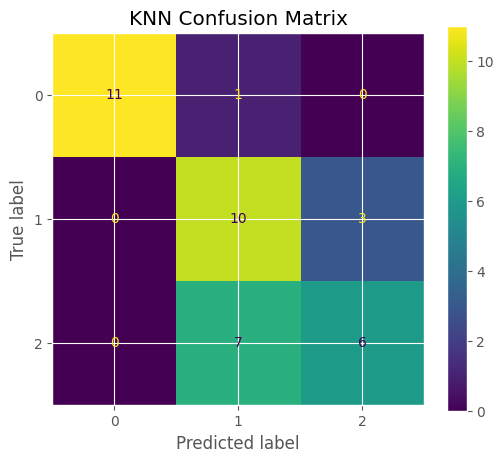

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test,pred_final,ax=ax)
plt.title('KNN Confusion Matrix')
plt.show()

**Description:** Confusion matrix shows how many samples were correctly or incorrectly classified for each class.

## 7. Decision Boundary Visualization

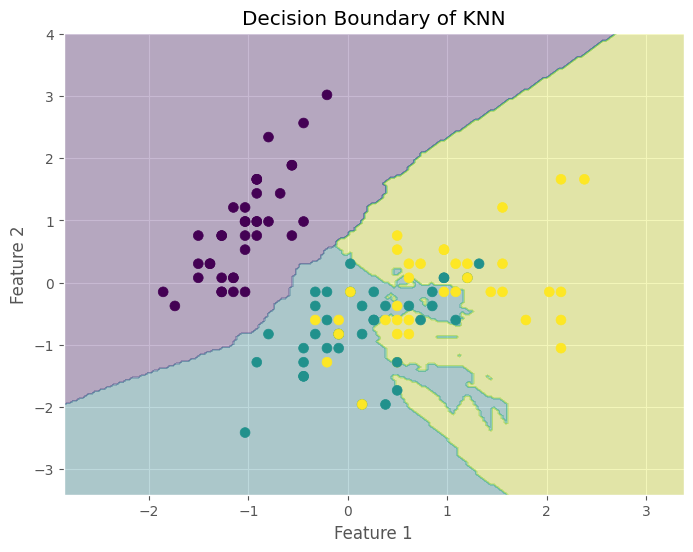

In [8]:
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min,x_max,200), np.linspace(y_min,y_max,200))
Z = final_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=50)
plt.title('Decision Boundary of KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Description:** Colored regions represent predicted classes. KNN creates flexible boundaries based on local neighbors.

## Important Concepts
- Instance-based learning
- Distance metrics (Euclidean distance)
- Need for feature scaling
- Choosing K value
- Overfitting vs underfitting

## Summary
KNN is simple and powerful for small to medium datasets. Performance depends strongly on feature scaling and selecting an appropriate K value.